In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import epiweeks as ew


In [2]:
#read in table
df = pd.read_csv('../data/importations/sarscov2_clusters_2024_11_12.tsv.gz', sep='\t')
df.head()

,cluster_id,sample_count,earliest_date,latest_date,growth_score,span,intro_confidence,parent_confidence,origin_gap,region,inferred_origin,inferred_origin_confidence,annotation_1,annotation_2,mutation_path,samples
0,Alabama_node_769572,1,2024-Oct-21,2024-Oct-21,0.250000,1,1.0,0.000000,3,Alabama,Pennsylvania,1.000000,24C (KP.3),KP.3.1,"A28881G,A28882G,C28883G<A19722G<G15372T<C23039G<",USA/AL-CDC-LC1124805/2024|PQ559948.1|2024-10-21
1,Alabama_node_1089253,1645,2021-May-04,2021-Dec-29,0.219236,2222,0.0,0.001256,1,Alabama,California,0.064426,21A (Delta),B.1.617.2,A11332G<T6402C<C8986T<G9053T<C7124T<C6402T<C27...,USA/AL-CDC-FG-203235/2021|OM057289.1|2021-12-1...
2,Alabama_node_1387063,821,2021-Jun-16,2021-Dec-30,0.160972,1144,1.0,0.000000,1,Alabama,indeterminate: 7 potential origins.,1.000000,21J (Delta),AY.3,G29050A<A11456G<C6402T<A11201G<,USA/AL-CDC-LC0291293/2021|OK454862.1|2021-09-1...
3,Alabama_node_947508,583,2021-Dec-14,2022-Apr-12,0.157813,856,1.0,0.000000,1,Alabama,indeterminate: 43 potential origins.,1.000000,21K (BA.1),BA.1,"G23048A<T5386G<A2832G,T13195C,A23048G,C24130A,...",USA/AL-CDC-ASC210699428/2022|OM820896.1|2022-0...
4,Alabama_node_775812,1,2024-Sep-30,2024-Sep-30,0.142857,1,1.0,0.333333,2,Alabama,Washington,0.333333,24B (JN.1.11.1),KP.1.1.3,"C7086T,C29614T<C5512T<T11964C<G1954A,C25925T<C...",USA/AL-USAFSAM-S23093/2024|PQ535910.1|2024-09-30


In [3]:
from pango_aliasor.aliasor import Aliasor
from typing import List, Dict
#of the variants in base_variants make a dictionary of all the subvariants that point to them
#the recombinant option is based on a request and likely not to work well.
def make_variant_base_map(base_variants: List[str], recombinant=False) -> Dict[str, str]:
    namer = Aliasor()
    namer.enable_expansion()
    all_rules = namer.partition_focus(base_variants, recombinant=recombinant)
    lineage_base_map = {k: v for v, ks in all_rules.items() for k in ks}
    
    for b in base_variants:
        if b not in lineage_base_map:
            lineage_base_map[b] = b
            
    return lineage_base_map

In [4]:
#regularize the variant names
target_list=['B.1.617.2','B.1.1.7']
replace_map = make_variant_base_map(target_list)
df['annotation_3']=df['annotation_2'].map(replace_map)

#make a week year column
df['earliest_date'] = pd.to_datetime(df['earliest_date'], errors='coerce')
df['week'] = df['earliest_date'].dt.strftime('%U')
df['year'] = df['earliest_date'].dt.strftime('%Y')
df['week_year'] = df['year'] + '-' + df['week']
df['week_year'] = pd.to_datetime(df['week_year'] + '-0', format='%Y-%U-%w').dt.strftime('%Y-%U')


In [5]:
#for Region Washington and annotation_2 = B.1.617.2 plot the number of rows per week
def plot_importations(df, region, annotation):
    df2 = df[df['annotation_3'] == annotation]
    df2 = df2[df2['region'] == region]
    df3 = df2.groupby(['week_year']).size().reset_index(name='importations')
    df3['seq_count']=df2.groupby(['week_year'])['sample_count'].sum().reset_index(name='sample_count')['sample_count']
    importations = df3['importations'].sum()
    df3 = df3.sort_values(by='week_year')
    df3.plot(x='week_year', y='importations', kind='bar')
    plt.xlabel('Week')
    plt.ylabel('Number of Importations')
    #on a second y axis plot the seq_count using a line plot
    plt.twinx()
    plt.plot(df3['week_year'], df3['seq_count'], color='r')
    #make y axis log scale
    plt.yscale('log')
    plt.ylabel('Number of Sequences')
    #label the minor ticks on y
    plt.minorticks_on()
    #turn on number labels of minor ticks on y
    plt.yticks(minor=True)
    plt.title(f'{annotation} Importations in {region} per Week (total {importations})')
    plt.show()
    #print value counts for the number of regions in df3
    print(df2['region'].value_counts())
    #create a new column in df3 that has the sum of sample_count for each week
    #drop the rows with more than 1000 sample_count
    #wa_df3 = wa_df3[wa_df3['sample_count'] < 1000]
    #create scatter plot
    df3.plot(x='seq_count', y='importations', kind='scatter')
    plt.xlabel('Number of Sequences')
    plt.ylabel('Number of Importations')
    plt.title(f'{annotation} Importations in {region} per Week vs Seqeunces (total {importations})')
    plt.show()
    #write out importations

In [16]:
def calc_schedule(df, region, annotations):
    df2 = df[df['region'] == region]
    df2 = df2[df2['annotation_3'].isin(annotations)]
    #get min earliest date
    min_date = df2['earliest_date'].min()
    #drop rows with earliest_date that are na
    df2 = df2.dropna(subset=['earliest_date'])
    #creat tick column by converting earliest_date to datetime and subtracting min_date to create integer
    df2['tick'] = ((pd.to_datetime(df2['earliest_date']) - min_date).dt.days)
    df2['tick'] = df2['tick'].astype(int)
    df3 = df2.groupby(['tick','annotation_3']).size().reset_index(name='importations')
    df3['seq_count']=df2.groupby(['tick'])['sample_count'].sum().reset_index(name='sample_count')['sample_count']
    #write schedule out to CSV
    df3.to_csv(f'../data/importations/schedules/{region}_schedule.csv', index=False)

In [17]:
annotations= ['B.1.617.2', 'B.1.1.7']
locations=["Washington","Virginia", "Minnesota", "Massachusetts","Georgia"]
for l in locations:
    calc_schedule(df, l, annotations)

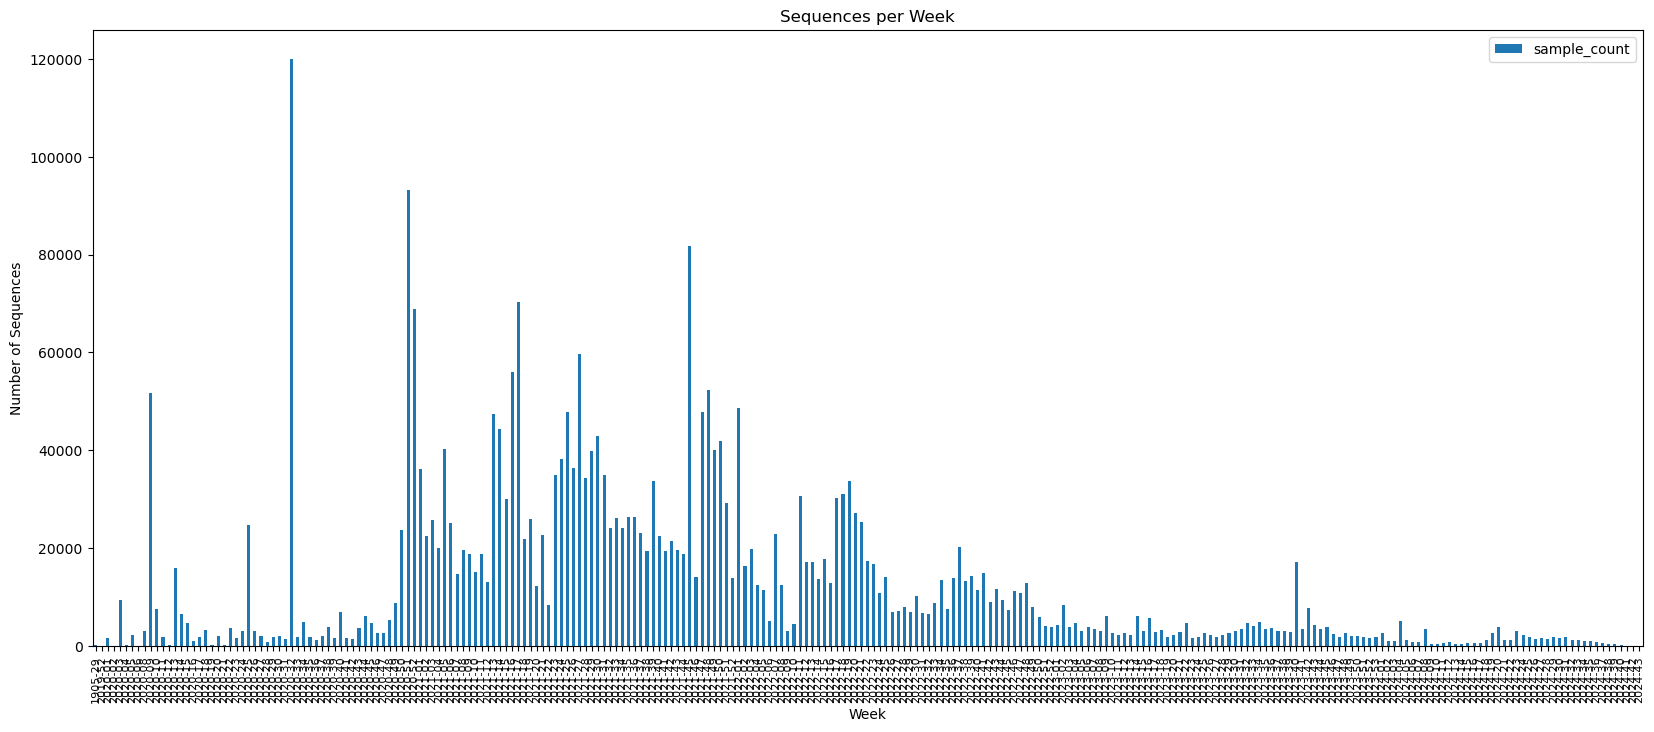

In [16]:
#plot the total number of sequences per week for all data
df3 = df.groupby(['week_year']).size().reset_index(name='count')
df3['sample_count']=df.groupby(['week_year'])['sample_count'].sum().reset_index(name='sample_count')['sample_count']
df3.plot(x='week_year', y='sample_count', kind='bar')
plt.xlabel('Week')
plt.ylabel('Number of Sequences')
plt.title('Sequences per Week')
#make plot wider
plt.gcf().set_size_inches(20, 8)
#make x-axis labels smaller font
plt.xticks(fontsize=8)
plt.show()


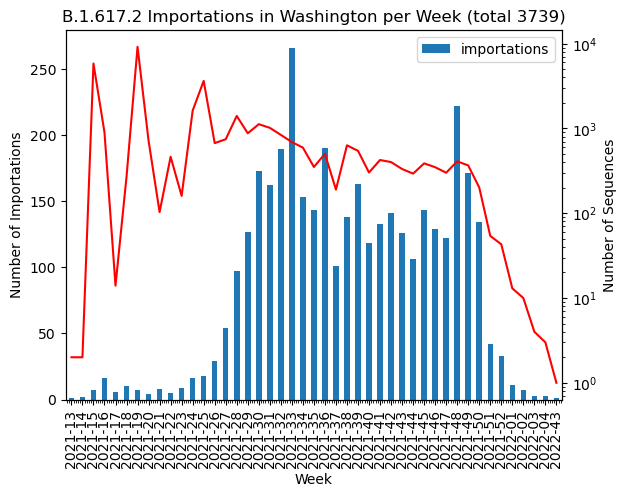

Washington    3739
Name: region, dtype: int64


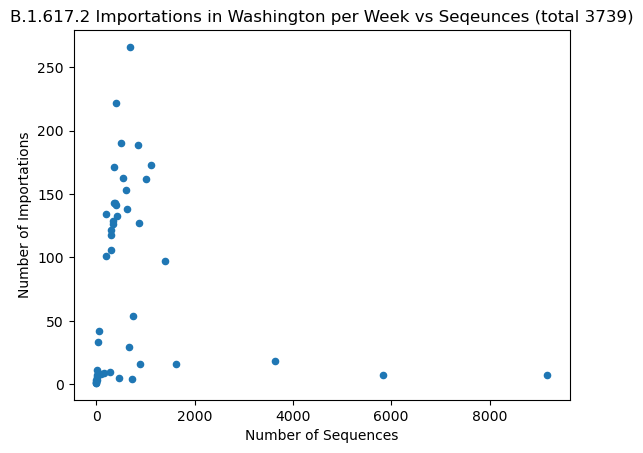

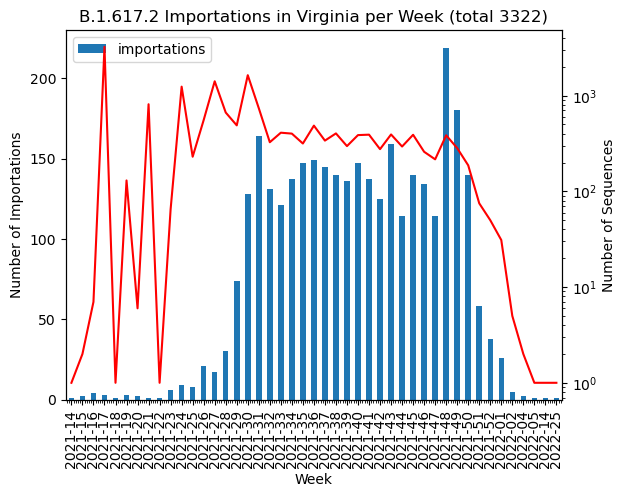

Virginia    3570
Name: region, dtype: int64


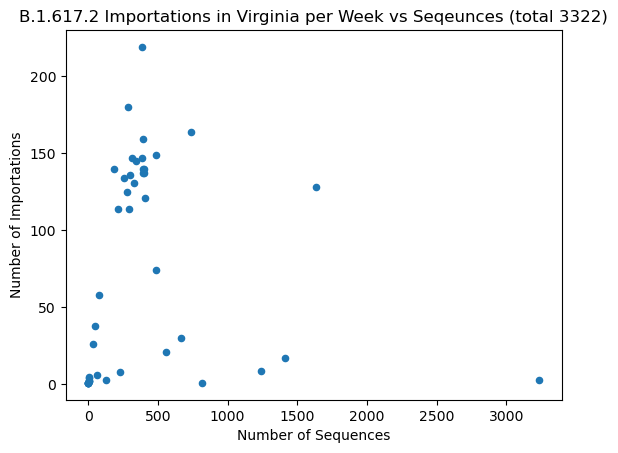

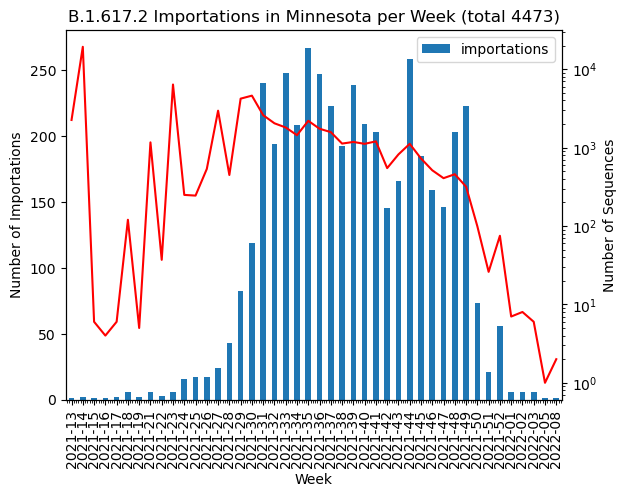

Minnesota    4473
Name: region, dtype: int64


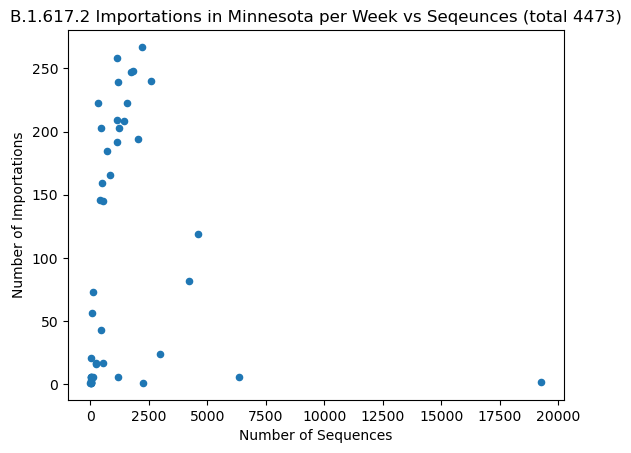

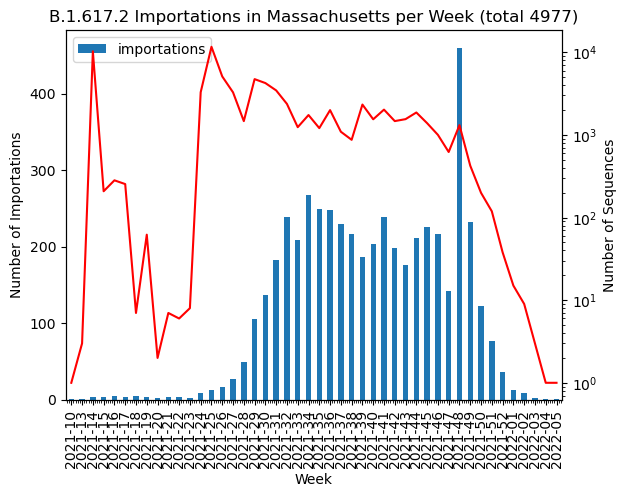

Massachusetts    4977
Name: region, dtype: int64


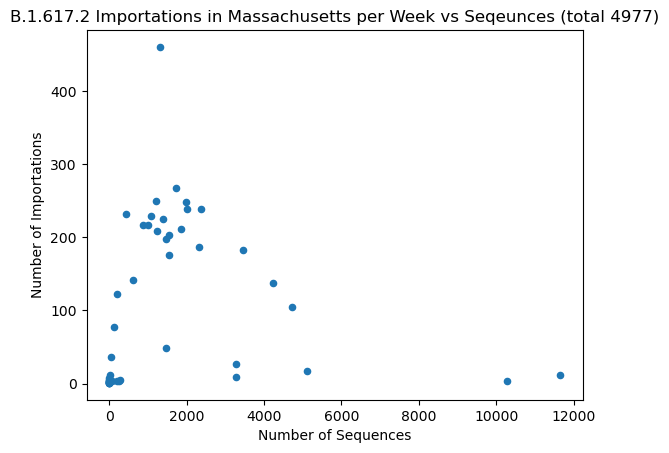

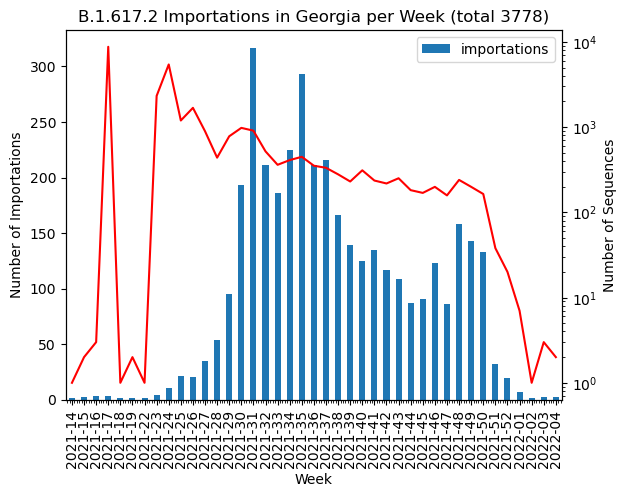

Georgia    3780
Name: region, dtype: int64


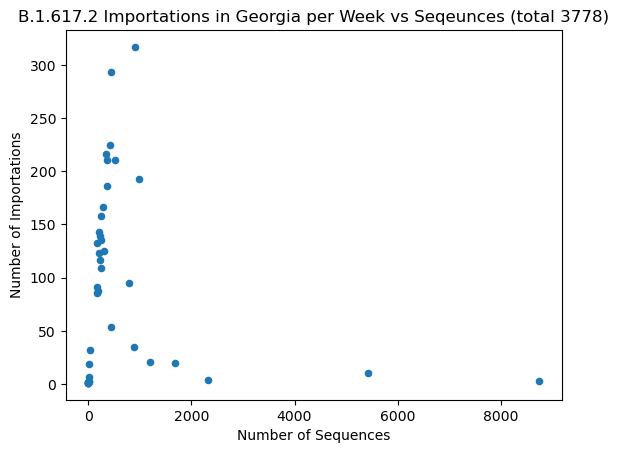

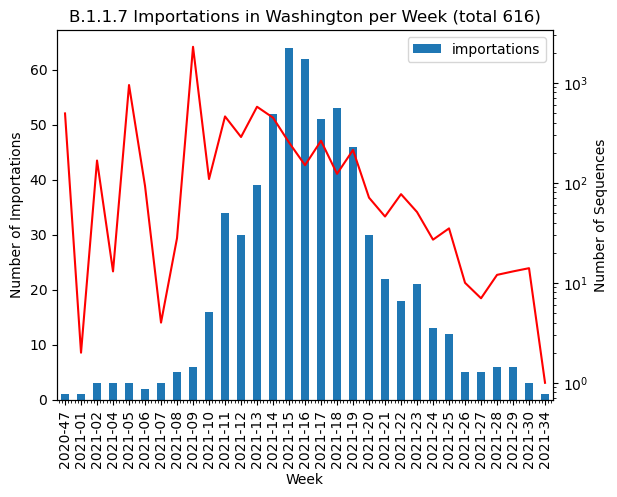

Washington    616
Name: region, dtype: int64


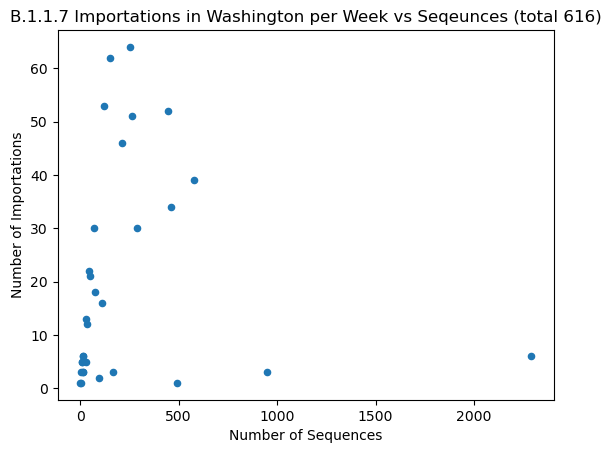

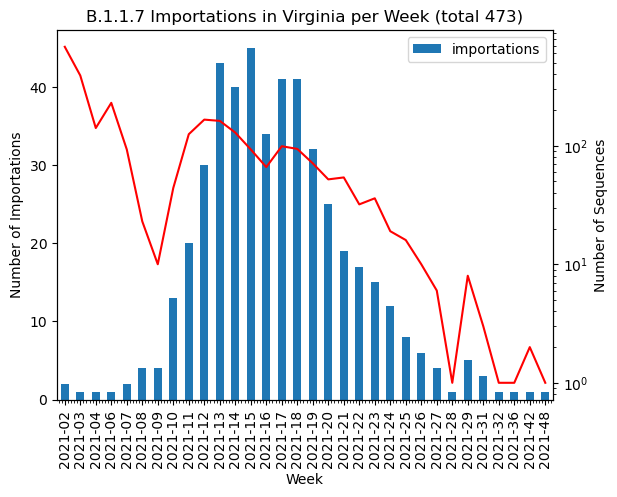

Virginia    582
Name: region, dtype: int64


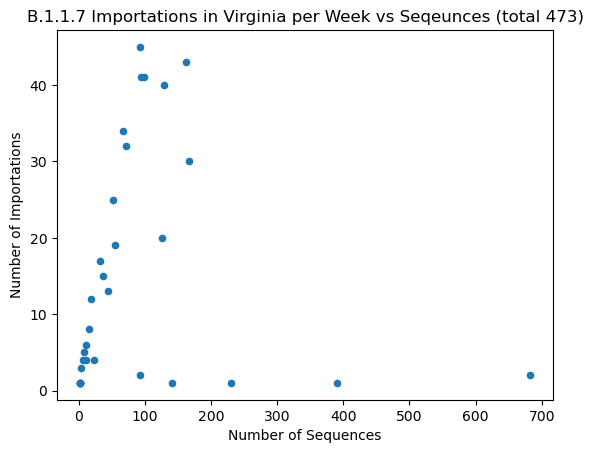

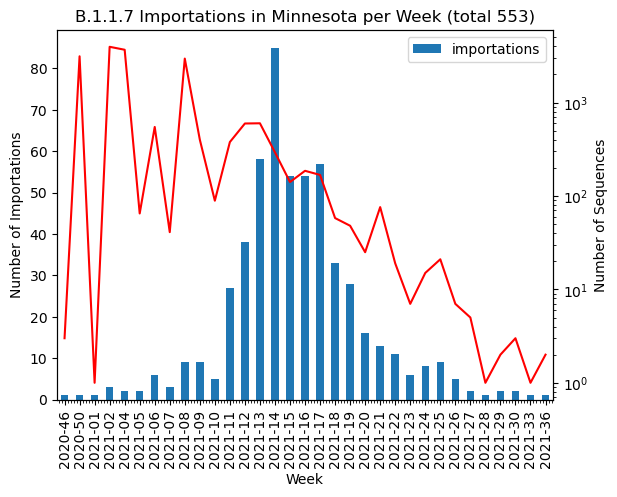

Minnesota    553
Name: region, dtype: int64


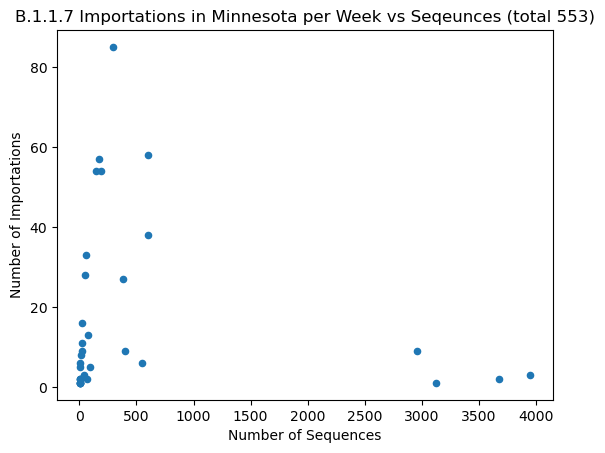

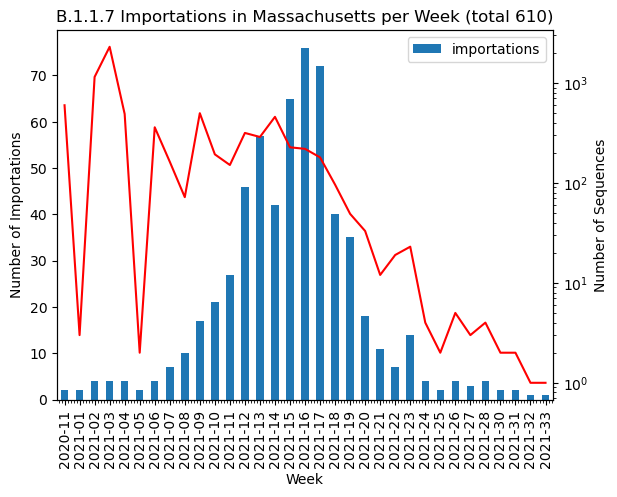

Massachusetts    610
Name: region, dtype: int64


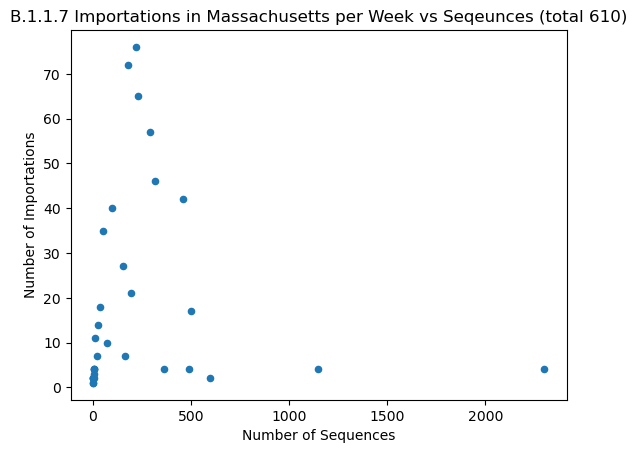

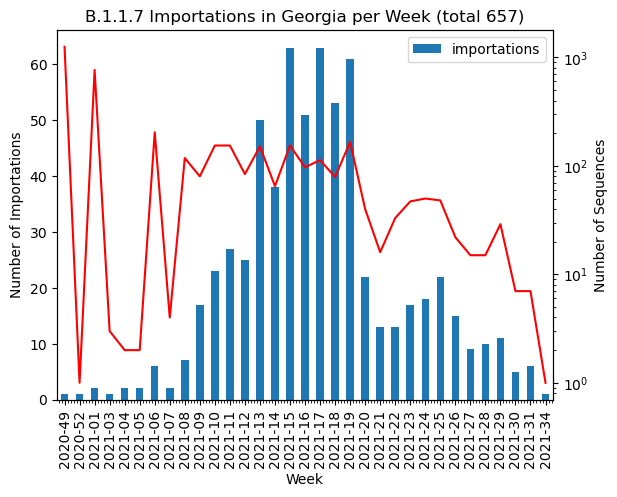

Georgia    658
Name: region, dtype: int64


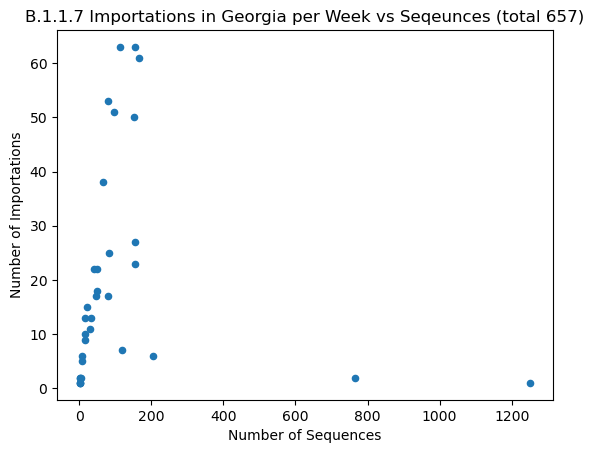

In [57]:
annotations= ['B.1.617.2', 'B.1.1.7']
locations=["Washington","Virginia", "Minnesota", "Massachusetts","Georgia"]
for a in annotations:
    for l in locations:
        plot_importations(df, l, a)